In [1]:
# Standard library
import os

# Data
import torch
import pandas as pd
import numpy as np
from datasets import load_from_disk

# ML
from sklearn.metrics import pairwise_distances
from sklearn_extra.cluster import KMedoids
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# NLP
from sentence_transformers import SentenceTransformer, util
import spacy

# Visualization
import matplotlib.pyplot as plt

In [2]:
DEBUG = True
SEED = 42
DATA_DIR = "./data"
TRAIN_SIZES = [10, 100, 1000, 10000]

In [3]:
def load_data(dataset_name):
    # Set dataset path
    path = f"{DATA_DIR}/{dataset_name}"
    # Load dataset
    dataset_dict = load_from_disk(path)

    # Extract split from the dataset name
    if "train" in dataset_name:
        split = "train"
    elif "val" in dataset_name:
        split = "val"
    elif "test" in dataset_name:
        split = "test"
    dataset = dataset_dict[split]

    # Shuffle train set or val set with seed for reproducibility
    if split == "train" or split == "val":
        dataset = dataset.shuffle(seed=42)

    return dataset

In [4]:
def build_dataset_name(base_name, split, num_example):
    return f"{base_name}_{split}_{num_example}"


def get_num_classes(dataset):
    labels = dataset["label"]
    return len(np.unique(labels))

In [5]:
if DEBUG:
    dataset_name = build_dataset_name("AgNews", "train", 10)
    train_set_10 = load_data(dataset_name)
    print(train_set_10)
    dataset_name = build_dataset_name("AgNews", "test", 1000)
    test_set = load_data(dataset_name)
    print(test_set)

    def print_examples(dataset):
        for example in dataset:
            print(example["text"])
            print(example["label"])

    print("-" * 100)
    print("Some train set examples:")
    print_examples(train_set_10)
    print("-" * 100)
    print("Some test set examples:")
    print_examples(test_set.select(range(10)))

Dataset({
    features: ['text', 'label'],
    num_rows: 12
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
----------------------------------------------------------------------------------------------------
Some train set examples:
Economy builds steam in KC Fed district The economy continued to strengthen in September and early October in the Great Plains and Rocky Mountain regions covered by the Tenth Federal Reserve District, the Federal Reserve Bank of Kansas City said Wednesday.
2
Mutombo says he #39;s being traded to Rockets; will back up, mentor &lt;b&gt;...&lt;/b&gt; Dikembe Mutombo, 38, has agreed to a sign-and-trade deal that will send him from the Chicago Bulls to Houston in exchange for Eric Piatkowski, Adrian Griffin and Mike Wilks, the Houston Chronicle reports.
1
Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington.
1
Bangladesh paralysed by strikes

In [6]:
def load_model(model_name):
    model_path = f"./models/{model_name}"
    if not os.path.exists(model_path):
        print(f"Model '{model_name}' not found locally. Downloading...")
        model = SentenceTransformer(model_name)  # Download from Hugging Face
        model.save(model_path)
    else:
        model = SentenceTransformer(model_path)
    print(f"'{model_name}' loaded and ready to use...")

    return model

In [7]:
def build_doc_classes(dataset, num_classes, preprocess_text=True):
    # Define an internal function for potential preprocessing
    def preprocess_texts(texts, nlp_model):
        processed_texts = []
        for doc in nlp_model.pipe(texts, disable=["ner", "parser"]):
            tokens = []
            for token in doc:
                if (
                    token.is_alpha
                    and not token.is_stop
                    and token.pos_ in {"NOUN", "PROPN", "ADJ"}
                    and len(token) > 2
                ):
                    # If the original token is all uppercase -> Title Case
                    if token.text.isupper():
                        tokens.append(token.lemma_.title())
                    else:
                        tokens.append(token.lemma_)
            
            processed_texts.append(" ".join(tokens))
        
        return processed_texts
    
    # Load preprocessing model
    if preprocess_text:
        nlp_model = spacy.load("en_core_web_sm")
    
    # Define a list of documents for each class
    doc_classes = []
    for i in range(num_classes):
        # Extract texts for class i
        texts = [example["text"] for example in dataset if example["label"] == i]
        # Optional preprocessing
        if preprocess_text:
            texts = preprocess_texts(texts, nlp_model)
        # Store the document corresponding to class i
        doc_classes.append(texts)

    return doc_classes

### K-Medoids Clustering

In [8]:
def run_k_medoids(distance_matrix, k, random_state):
    # Initialize the KMedoids clustering model
    kmedoids = KMedoids(
        n_clusters=k,
        metric="precomputed",   # Precomputed distance matrix
        init="k-medoids++",
        random_state=random_state
    )

    # Compute distances between points and medoids.
    # Assign each point to the nearest cluster.
    # For each cluster, evaluate each point as a potential medoid and select the one
    # that minimizes the sum of distances to all other points in the cluster.
    # Repeat assignment and medoid update steps until convergence.
    kmedoids.fit(distance_matrix)
    
    # Array of length n: cluster assignment for each data point
    labels = kmedoids.labels_
    # Indices of the medoid points in the dataset
    medoid_indices = kmedoids.medoid_indices_

    return labels, medoid_indices

### K-Elbow Method

In [9]:
def run_k_elbow_method(distance_matrix, min_k, max_k, random_state, n_init, plot=True):
    # Convert to numpy
    distance_matrix = np.asarray(distance_matrix)
    # Number of data points
    n = distance_matrix.shape[0]
    ks = []
    costs = []
    for k in range(min_k, max_k + 1):
        run_costs = []
        for i in range(n_init):
            # Update seed
            seed = int(random_state + i)
            # Run k-medoids with the current k
            labels, medoid_indices = run_k_medoids(distance_matrix, k, random_state=seed)

            # Convert to numpy
            labels = np.asarray(labels)
            medoid_indices = np.asarray(medoid_indices, dtype=int)

            # Medoid assigned to a point
            per_point_medoid = medoid_indices[labels]
            # Distance between each point and its medoid
            per_point_dist = distance_matrix[np.arange(n), per_point_medoid]
            # Compute total cost
            total_cost = float(per_point_dist.sum())

            # Store the total cost for the current k and initialization
            run_costs.append(total_cost)
        
        # Select the minimum cost for the current k
        min_cost = float(np.min(run_costs))
        # Track k values and corresponding costs
        ks.append(k)
        costs.append(min_cost)

    # Convert to numpy
    ks = np.array(ks)
    costs = np.array(costs)

    # Line passing through P1 and P2
    p1 = np.array([ks[0], costs[0]])
    p2 = np.array([ks[-1], costs[-1]])
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    
    # Compute distances of points (k, cost(k)) from the line
    dists = np.abs(np.cross(line_vec, np.column_stack((ks, costs)) - p1)) / line_len
    # Elbow: point (k, cost(k)) with the maximum distance
    elbow_idx = int(np.argmax(dists))
    suggested_k = int(ks[elbow_idx])

    if plot:
        plt.figure(figsize=(8,4.5))
        plt.plot(ks, costs, marker='o', linewidth=2)
        plt.scatter([suggested_k], [costs[elbow_idx]], color='red', zorder=5)
        plt.text(suggested_k, costs[elbow_idx], f"  elbow: k={suggested_k}", va='bottom', color='red')
        plt.xlabel("k")
        plt.ylabel("Total cost (sum distance point->medoid{})")
        plt.title("Elbow method (k vs total cost)")
        plt.grid(alpha=0.3)
        plt.show()

    return suggested_k, costs


In [10]:
def init_k_elbow_params(num_examples):
    min_k = 1
    if num_examples > 10:
        max_k = 10
    else:
        max_k = 3
    n_init = 60
    random_state = 42

    params = {
        "min_k": min_k,
        "max_k": max_k,
        "n_init": n_init,
        "random_state": random_state
    }

    return params


def compute_distance_matrix_classes(doc_classes, embedding_model, num_classes):
    distance_matrix_classes = []
    for i in range(num_classes):
        # Embeddings of texts for the class i
        embeddings = embedding_model.encode(doc_classes[i], convert_to_numpy=True)        
        # Pairwise distance matrix between texts, metric: cosine distance = 1 - cosine similarity
        distance_matrix = pairwise_distances(embeddings, metric="cosine")

        distance_matrix_classes.append(distance_matrix)

    return distance_matrix_classes


def find_suggested_k_values(distance_matrix_classes, num_classes, k_elbow_params):
    min_k = k_elbow_params["min_k"]
    max_k = k_elbow_params["max_k"]
    n_init = k_elbow_params["n_init"]
    random_state = k_elbow_params["random_state"]

    k_values = []
    # Apply the elbow method for each class
    for i in range(num_classes):
        suggested_k, costs = run_k_elbow_method(distance_matrix_classes[i], min_k, max_k, random_state, n_init, plot=True)
        print(f"Suggested k for class {i}: {suggested_k}")
        # Debug
        print(costs)

        k_values.append(suggested_k)

    return k_values


def extract_medoid_texts(doc_classes, distance_matrix_classes, k_values):
    medoids_classes = []
    # Retrieve the distance matrix and the suggested k for each class
    for i, (distance_matrix, k) in enumerate(zip(distance_matrix_classes, k_values)):
        # Run k-medoids
        _, medoid_indices = run_k_medoids(distance_matrix, k, random_state=0)
        # Medoid texts
        texts = doc_classes[i]
        medoid_texts = [texts[i] for i in medoid_indices]

        # Save the medoid texts for each class
        medoids_classes.append(medoid_texts)

    return medoids_classes

##### Define a function to obtain medoid labels for each training set

In [11]:
def run_medoid_labels_per_train_set(train_sets, embedding_model):
    # List of labels corresponding to medoids for each training set
    medoid_labels_train_sets = []
    # Get number of classes
    num_classes = get_num_classes(train_sets[10])
    # For each train set
    for n in TRAIN_SIZES:
        print(f"Train set size {n}:\n")
        # Select the i-th training set
        train_set = train_sets[n]
        
        # Build a document for each class
        doc_classes = build_doc_classes(train_set, num_classes)
        # Compute distance matrix for each class
        distance_matrix_classes = compute_distance_matrix_classes(doc_classes, embedding_model, num_classes)

        # Initialize k-elbow method parameters
        k_elbow_params = init_k_elbow_params(n)
        # Run k-elbow method to find the suggested k for each class
        k_values = find_suggested_k_values(distance_matrix_classes, num_classes, k_elbow_params)

        # Run k-medoids using the suggested k values found to extract medoid texts for each class
        medoids_classes = extract_medoid_texts(doc_classes, distance_matrix_classes, k_values)

        # Labels defined by the medoids of each class in string format
        medoid_labels = []
        for medoids in medoids_classes:
            label_i = ", ".join(medoids)
            medoid_labels.append(label_i)

        # Store the new labels obtained from the i-th training set
        medoid_labels_train_sets.append(medoid_labels)

        print("-"*100)


    return medoid_labels_train_sets

### Evaluator

In [12]:
class MultiMetricEvaluator:
    def __init__(self, dataset, labels, name):
        self.dataset = dataset
        self.labels = labels
        self.name = name

    def __call__(self, model):
        pairs = self._compute_predictions(model)
        acc, prec, rec, f1 = self._compute_metrics(pairs)

        return {"accuracy" : acc, "precision" : prec, "recall" : rec, "f1_score" : f1}
    
    def _compute_predictions(self, model):
        # Compute label embeddings
        label_embeddings = model.encode(self.labels, convert_to_tensor=True)

        results = []
        for sample in self.dataset:
            text = sample['text']
            true_label = sample['label']

            # Compute text embeddings
            text_embedding = model.encode(text, convert_to_tensor=True)

            # Compute the cosine similarity between the text and each label embedding
            similarities = util.cos_sim(text_embedding, label_embeddings)
            
            # Predict the label with the highest similarity
            predicted_label = torch.argmax(similarities).item()

            # Save the pair (predicted label, correct label)
            results.append((predicted_label, true_label))
            
        return results

    def _compute_metrics(self, pairs):
        # Extraction of each pair (predicted label, correct label)
        predictions, true_labels = zip(*pairs)

        # Accuracy
        accuracy = accuracy_score(true_labels, predictions)
        # Use macro for precision, recall ed F1 score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            true_labels,
            predictions,
            average='macro',
            zero_division=0
        )

        return accuracy, precision, recall, f1_score

In [13]:
def print_metrics(metrics):
    accuracy = metrics["accuracy"]
    precision = metrics["precision"]
    recall = metrics["precision"]
    f1_score = metrics["f1_score"]

    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1_score}")

---

In [14]:
model_list = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
    "sentence-t5-base",
    "BAAI/bge-base-en",
]

In [15]:
# List of loaded models
models = []
for model_name in model_list:
    embedding_model = load_model(model_name)
    models.append(embedding_model)

'all-MiniLM-L6-v2' loaded and ready to use...
'all-mpnet-base-v2' loaded and ready to use...
'sentence-t5-base' loaded and ready to use...
'BAAI/bge-base-en' loaded and ready to use...


### Run K-medoids clustering on each training set

all-MiniLM-L6-v2:
Train set size 10:



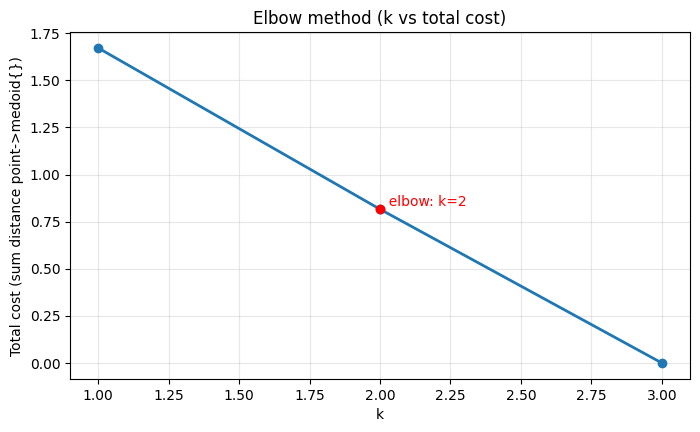

Suggested k for class 0: 2
[1.67210364 0.8160761  0.        ]


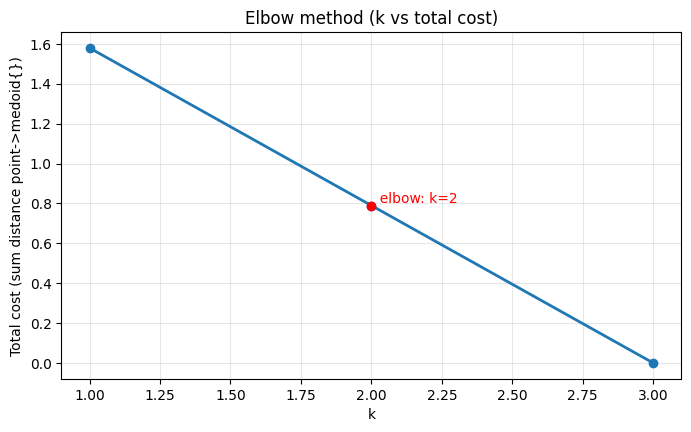

Suggested k for class 1: 2
[1.57997167 0.7897011  0.        ]


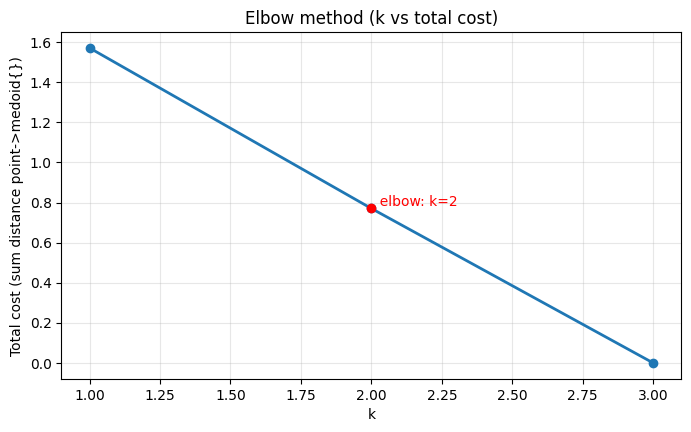

Suggested k for class 2: 2
[1.57120717 0.77059281 0.        ]


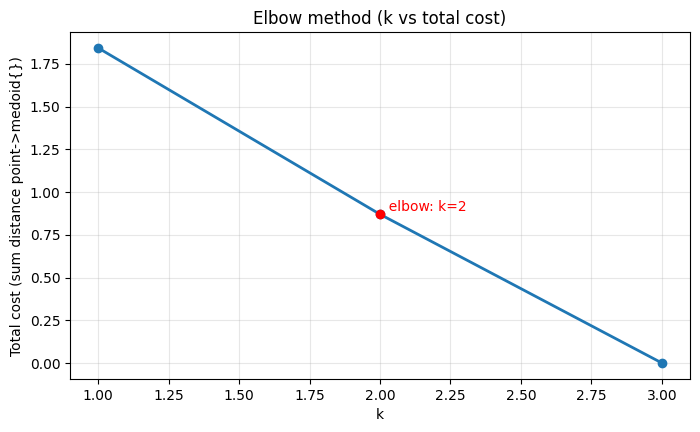

Suggested k for class 3: 2
[1.84296632 0.86978334 0.        ]
----------------------------------------------------------------------------------------------------
Train set size 100:



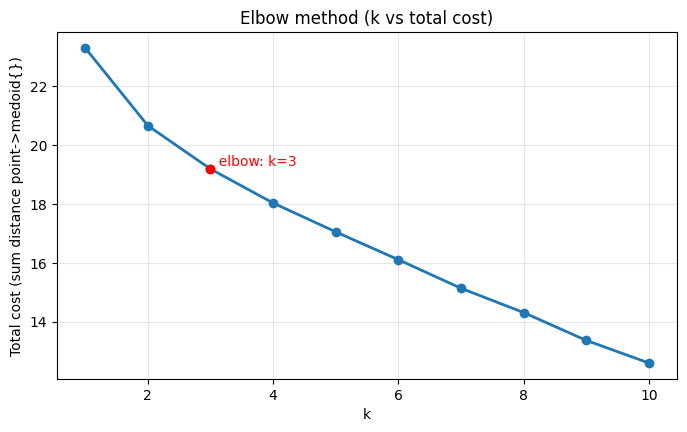

Suggested k for class 0: 3
[23.29601669 20.66000366 19.18982506 18.03450966 17.054842   16.1108036
 15.1411171  14.31682587 13.37145901 12.60477257]


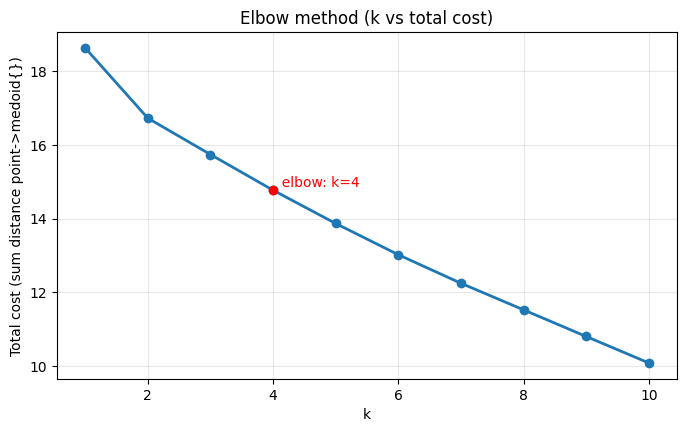

Suggested k for class 1: 4
[18.62838364 16.72485733 15.74019527 14.77152157 13.86997128 13.02280712
 12.24926472 11.52830124 10.80650997 10.08809662]


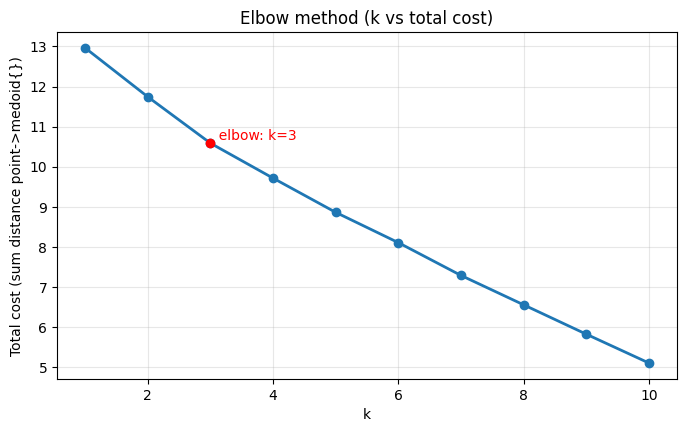

Suggested k for class 2: 3
[12.96218109 11.74317551 10.58808708  9.71644402  8.8641758   8.10901928
  7.29157162  6.55953312  5.82771301  5.10909796]


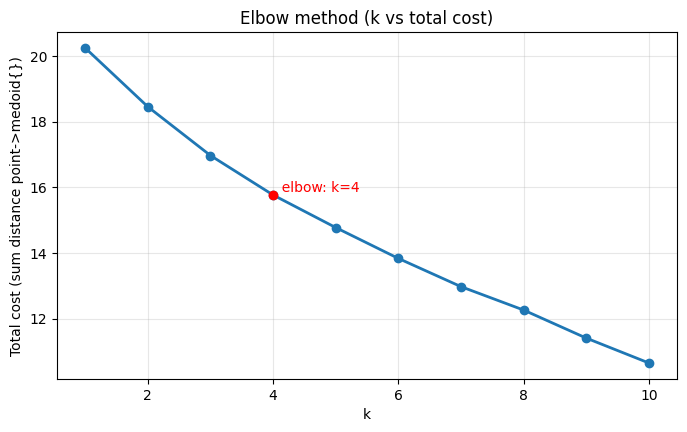

Suggested k for class 3: 4
[20.24918747 18.45840836 16.97306442 15.77041435 14.77813435 13.83795166
 12.97830486 12.26519012 11.4112978  10.65268707]
----------------------------------------------------------------------------------------------------
Train set size 1000:



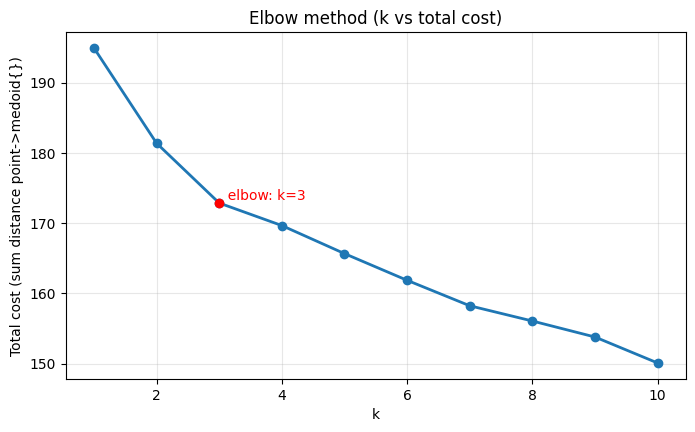

Suggested k for class 0: 3
[194.95709229 181.39743042 172.87930298 169.67390442 165.68148804
 161.87875366 158.2543335  156.0827179  153.80456543 150.10774231]


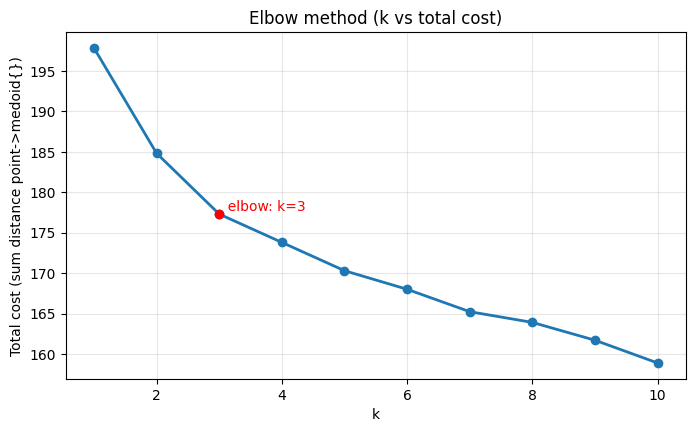

Suggested k for class 1: 3
[197.84289551 184.83154297 177.31787109 173.82041931 170.32342529
 168.0269928  165.259552   163.9332428  161.73165894 158.92077637]


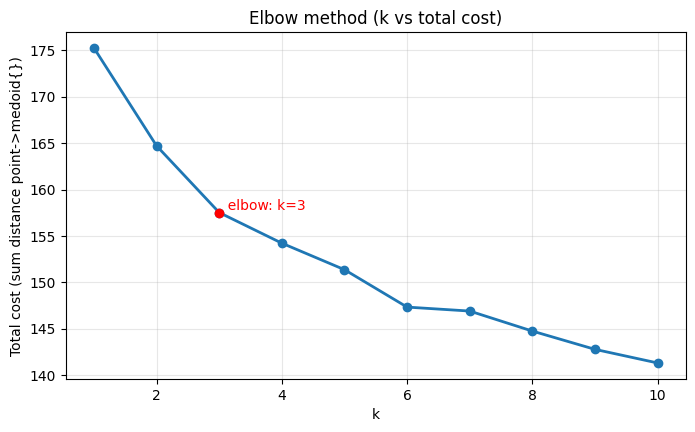

Suggested k for class 2: 3
[175.25973511 164.71084595 157.52227783 154.22161865 151.36694336
 147.33433533 146.90682983 144.74934387 142.77920532 141.31175232]


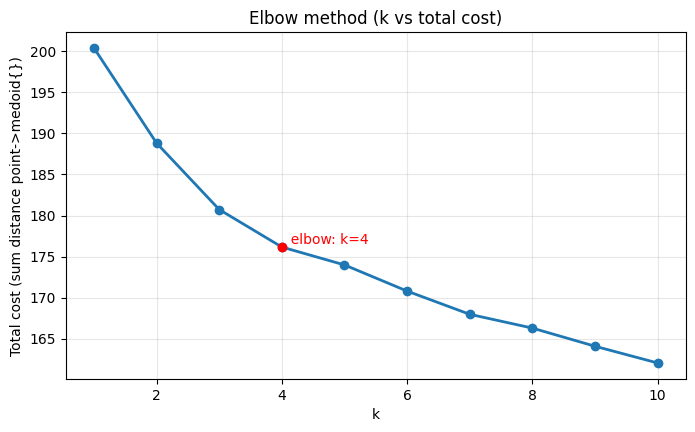

Suggested k for class 3: 4
[200.40542603 188.82293701 180.7322998  176.16394043 173.98760986
 170.80206299 167.97529602 166.29624939 164.08711243 162.04803467]
----------------------------------------------------------------------------------------------------
Train set size 10000:



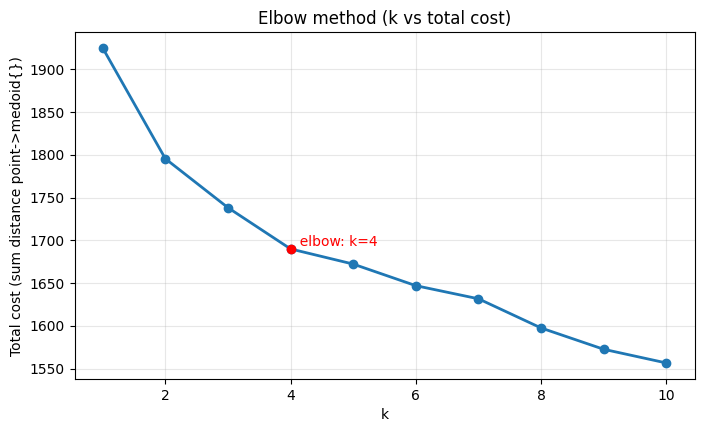

Suggested k for class 0: 4
[1924.88647461 1795.44189453 1738.16796875 1689.92614746 1672.20812988
 1646.96875    1631.61804199 1597.50146484 1572.58410645 1556.58496094]


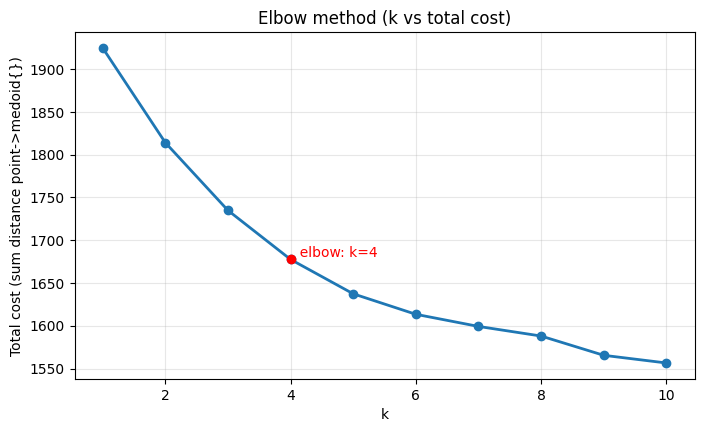

Suggested k for class 1: 4
[1924.79174805 1814.11193848 1734.88562012 1677.56872559 1637.38964844
 1613.43164062 1599.24975586 1588.02172852 1565.48974609 1556.52563477]


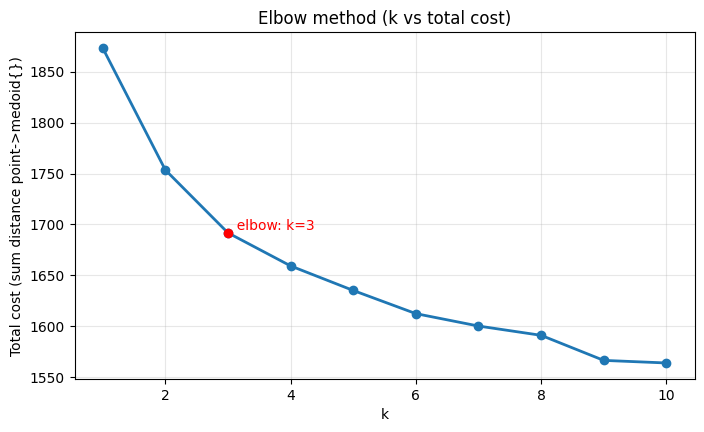

Suggested k for class 2: 3
[1873.42333984 1753.52539062 1691.69116211 1659.20080566 1635.0703125
 1612.29577637 1600.09790039 1590.97290039 1566.33288574 1563.78894043]


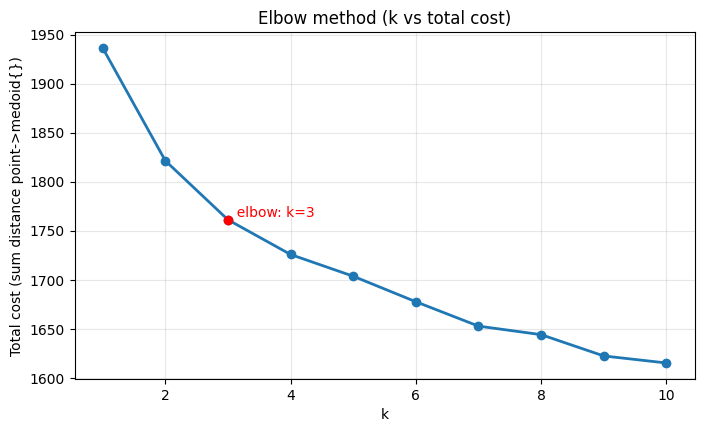

Suggested k for class 3: 3
[1936.62597656 1821.55810547 1761.33666992 1725.9128418  1703.7364502
 1677.71484375 1652.82495117 1644.13684082 1622.40209961 1615.23193359]
----------------------------------------------------------------------------------------------------
Medoid labels found for all-MiniLM-L6-v2:
- on train set size 10:
Bangladesh strike opposition activist town city Bangladesh halt day people explosion political rally, Putin power play russia safe Russia barrage terrorist attack school massacre Beslan
Mutombo Rockets mentor Dikembe Mutombo trade deal Chicago Bulls Houston exchange Eric Piatkowski Adrian Griffin Mike Wilks Houston Chronicle, wrong Athens Matt Emmons calm right target
economy steam Fed district economy September early October Great Plains Rocky Mountain region Tenth Federal Reserve District Federal Reserve Bank Kansas City Wednesday, Rbc Centura Ceo Raleigh head Rbc Centura Bank successor bank Raleigh Rocky Mount bank
pitch Apple New iTunes ad baseball gam

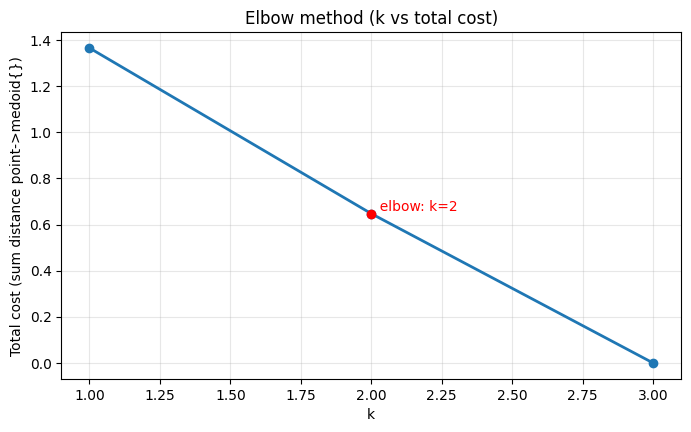

Suggested k for class 0: 2
[1.36531103 0.64725947 0.        ]


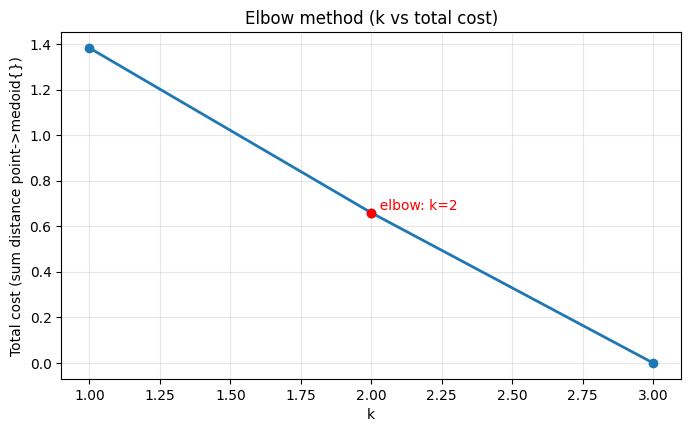

Suggested k for class 1: 2
[1.38257253 0.65928197 0.        ]


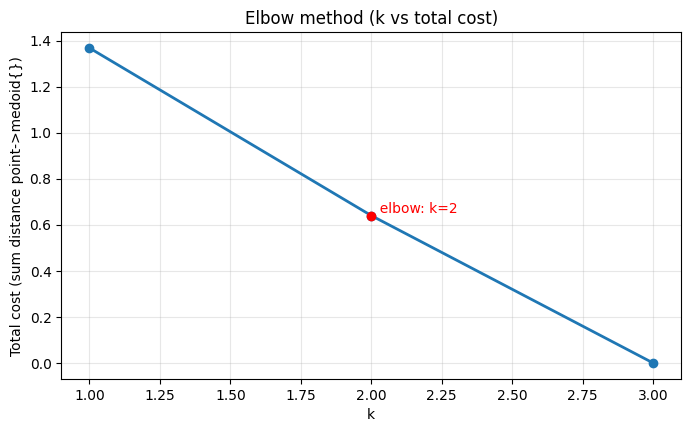

Suggested k for class 2: 2
[1.3683883  0.64033669 0.        ]


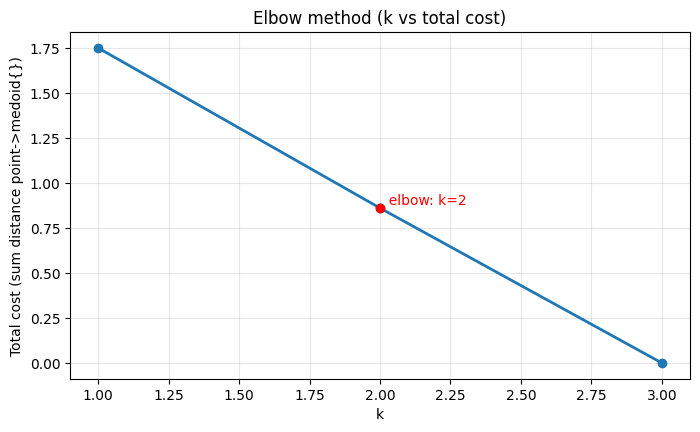

Suggested k for class 3: 2
[1.75152469 0.86131108 0.        ]
----------------------------------------------------------------------------------------------------
Train set size 100:



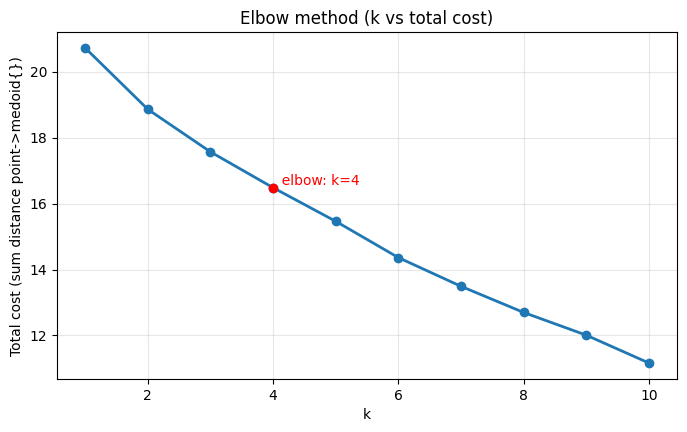

Suggested k for class 0: 4
[20.7255497  18.86337471 17.5713501  16.48386955 15.46401596 14.3626709
 13.49055958 12.69723988 12.00759411 11.16296768]


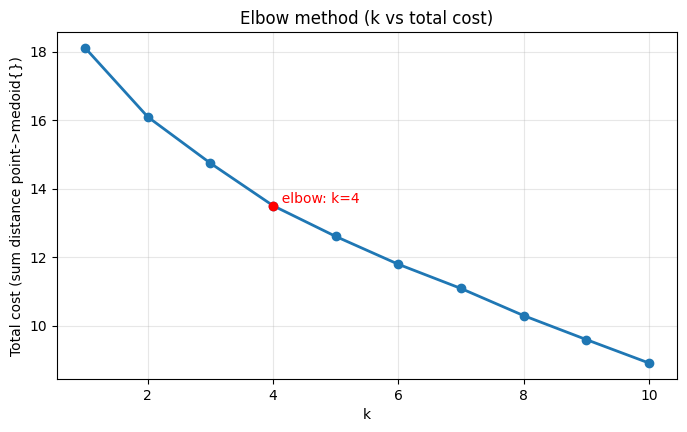

Suggested k for class 1: 4
[18.10731888 16.09353256 14.74300575 13.50372887 12.60710335 11.79398823
 11.0877409  10.29647923  9.59678841  8.91313457]


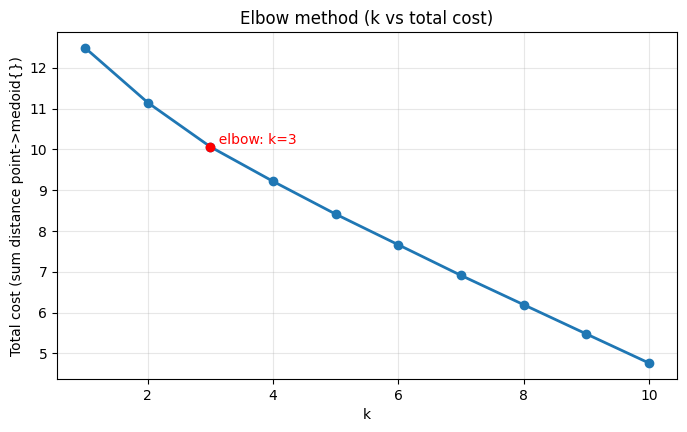

Suggested k for class 2: 3
[12.48604774 11.1459837  10.06213665  9.21635628  8.41277695  7.66210175
  6.91172886  6.19397545  5.47775602  4.76483679]


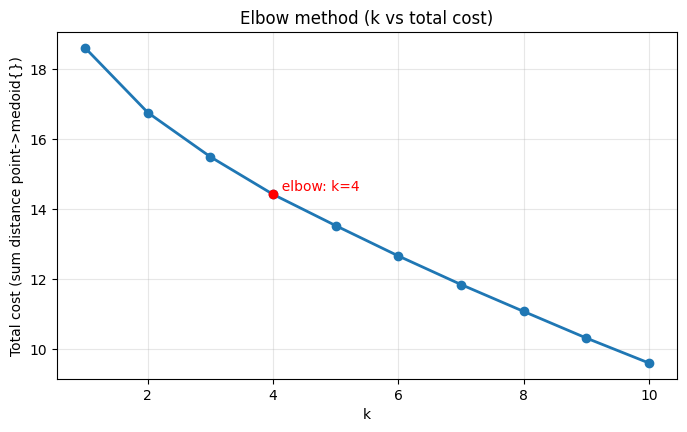

Suggested k for class 3: 4
[18.60044861 16.75502396 15.49063301 14.4200325  13.52797318 12.66234779
 11.84673309 11.07856369 10.31925678  9.60638714]
----------------------------------------------------------------------------------------------------
Train set size 1000:



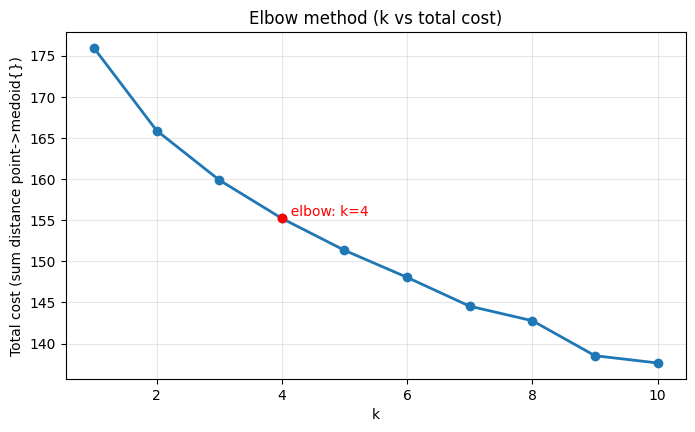

Suggested k for class 0: 4
[175.96107483 165.91604614 159.89694214 155.22415161 151.34335327
 148.04931641 144.54342651 142.77578735 138.51905823 137.63363647]


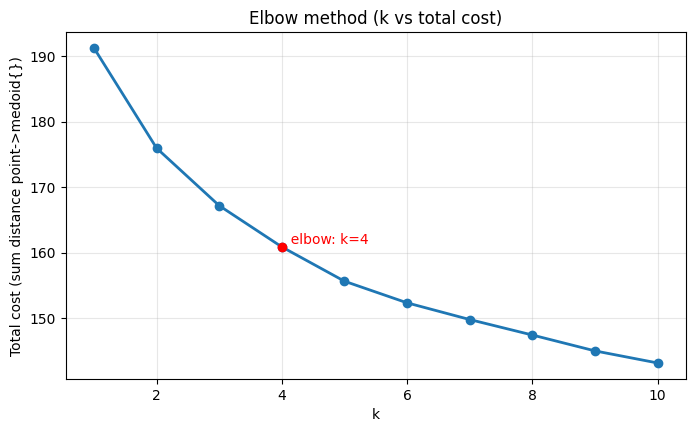

Suggested k for class 1: 4
[191.26115417 175.97702026 167.19741821 160.89932251 155.66389465
 152.36541748 149.81578064 147.45321655 145.0320282  143.18836975]


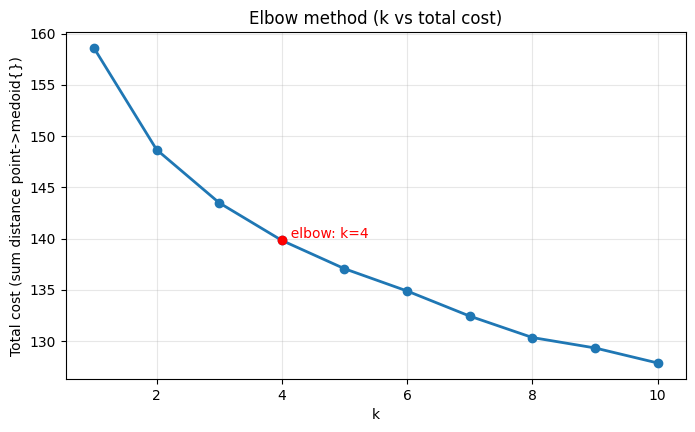

Suggested k for class 2: 4
[158.6030426  148.67900085 143.48861694 139.81776428 137.05891418
 134.88323975 132.43225098 130.34216309 129.32284546 127.85730743]


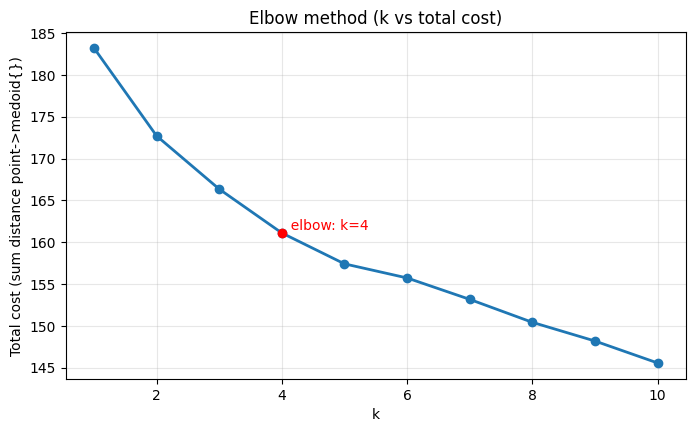

Suggested k for class 3: 4
[183.22685242 172.71925354 166.36018372 161.11309814 157.42468262
 155.73803711 153.17935181 150.43453979 148.1998291  145.57637024]
----------------------------------------------------------------------------------------------------
Train set size 10000:



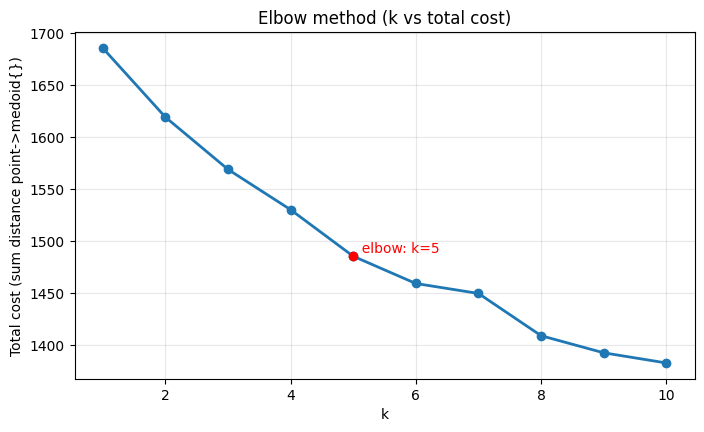

Suggested k for class 0: 5
[1686.02160645 1619.54125977 1569.25244141 1530.4675293  1485.67529297
 1459.48266602 1449.89868164 1409.25964355 1392.8112793  1383.02954102]


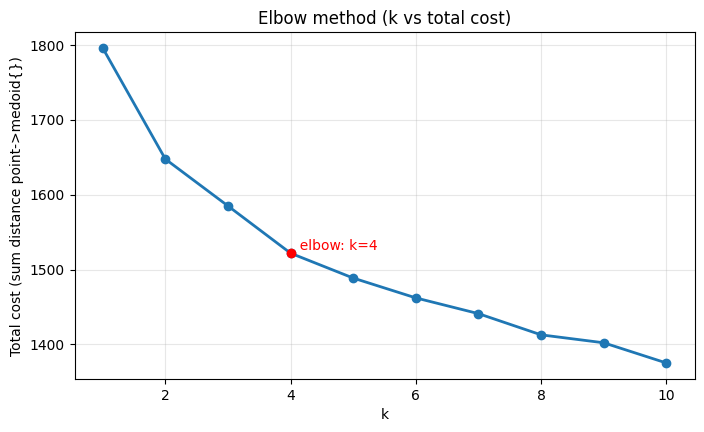

Suggested k for class 1: 4
[1795.93469238 1647.56396484 1584.9407959  1521.82873535 1488.6081543
 1462.1105957  1441.08349609 1412.76611328 1402.16430664 1375.19812012]


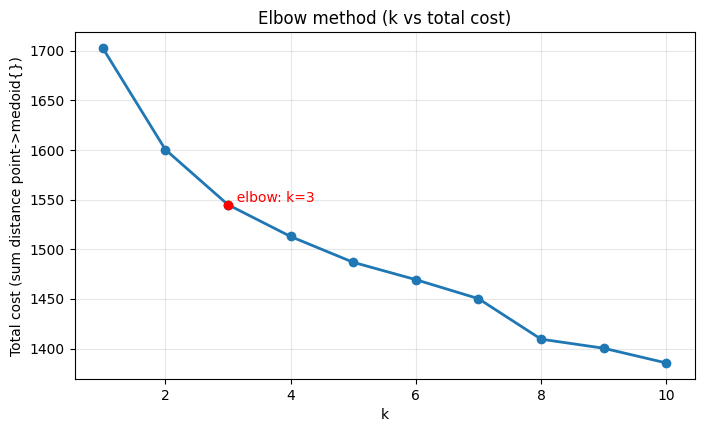

Suggested k for class 2: 3
[1702.76672363 1600.41882324 1544.890625   1512.83728027 1486.83105469
 1469.35766602 1450.20349121 1409.39453125 1400.27539062 1385.421875  ]


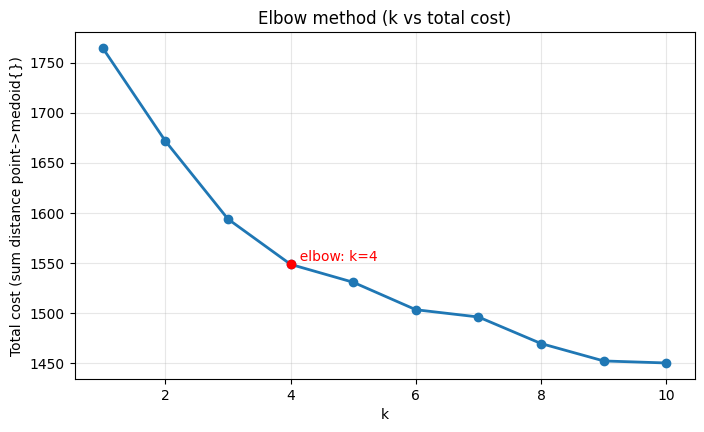

Suggested k for class 3: 4
[1764.65771484 1671.8001709  1593.91760254 1548.68933105 1530.80175781
 1503.40222168 1496.13134766 1469.62219238 1452.26831055 1450.24377441]
----------------------------------------------------------------------------------------------------
Medoid labels found for all-mpnet-base-v2:
- on train set size 10:
Bangladesh strike opposition activist town city Bangladesh halt day people explosion political rally, african blunder public broadcaster Sabc apologise news bulletin footage American Iraq
Mutombo Rockets mentor Dikembe Mutombo trade deal Chicago Bulls Houston exchange Eric Piatkowski Adrian Griffin Mike Wilks Houston Chronicle, wrong Athens Matt Emmons calm right target
economy steam Fed district economy September early October Great Plains Rocky Mountain region Tenth Federal Reserve District Federal Reserve Bank Kansas City Wednesday, Rbc Centura Ceo Raleigh head Rbc Centura Bank successor bank Raleigh Rocky Mount bank
pitch Apple New iTunes ad baseball

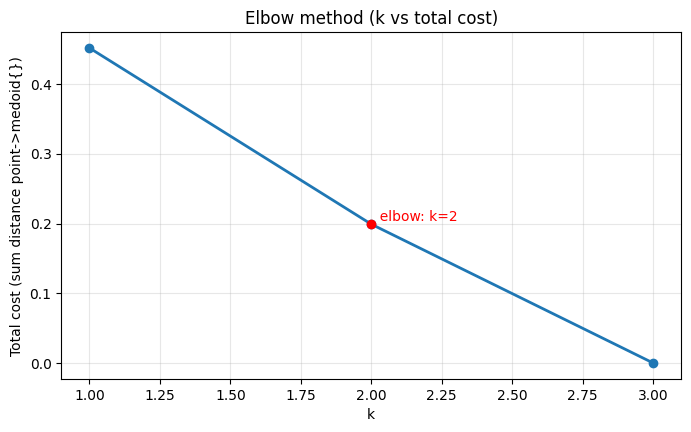

Suggested k for class 0: 2
[0.45186222 0.19908547 0.        ]


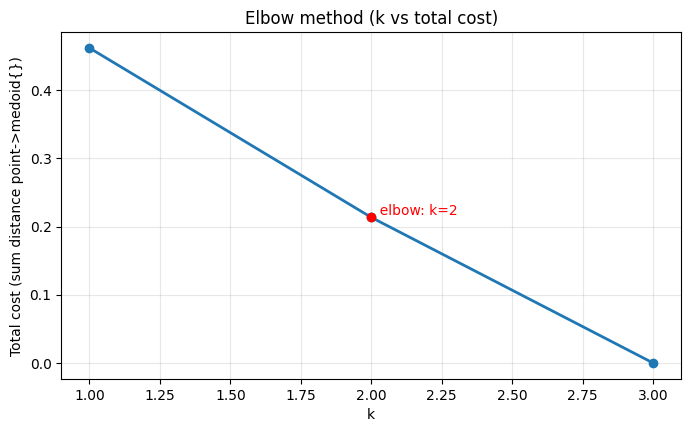

Suggested k for class 1: 2
[0.46172911 0.21339476 0.        ]


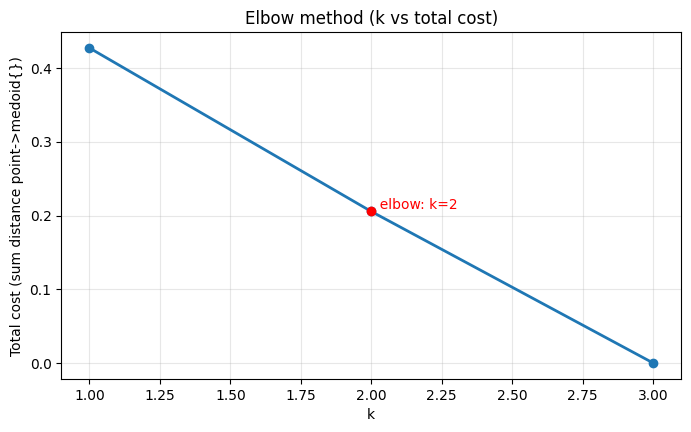

Suggested k for class 2: 2
[0.42724997 0.20549536 0.        ]


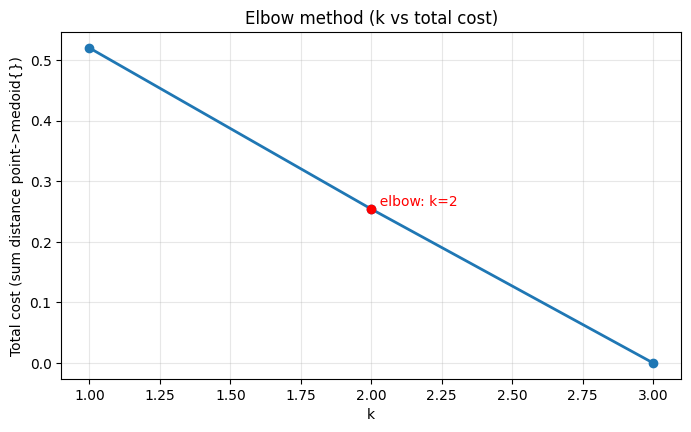

Suggested k for class 3: 2
[0.52033854 0.25428283 0.        ]
----------------------------------------------------------------------------------------------------
Train set size 100:



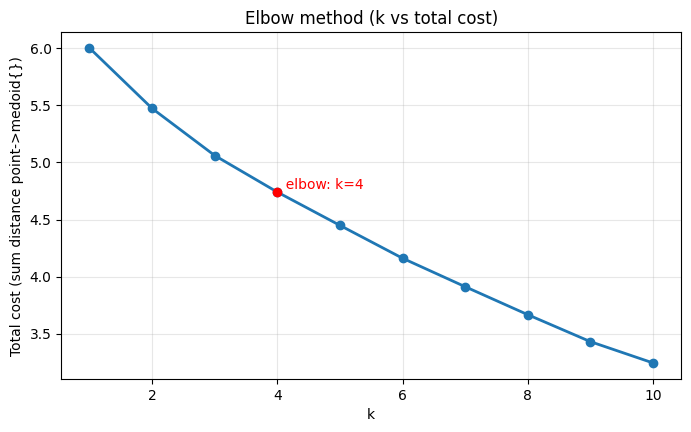

Suggested k for class 0: 4
[6.0031662  5.47369146 5.06096411 4.74049616 4.44861364 4.16067839
 3.9112134  3.6660738  3.4297924  3.24319839]


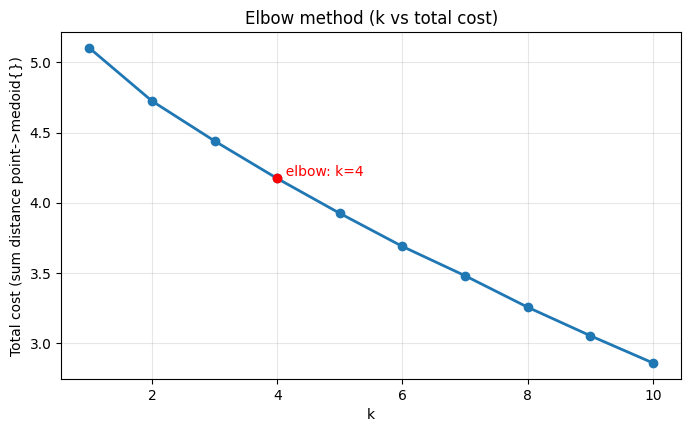

Suggested k for class 1: 4
[5.10311604 4.7253108  4.44046307 4.17345476 3.92503834 3.68901157
 3.48047519 3.25616312 3.05316544 2.85907054]


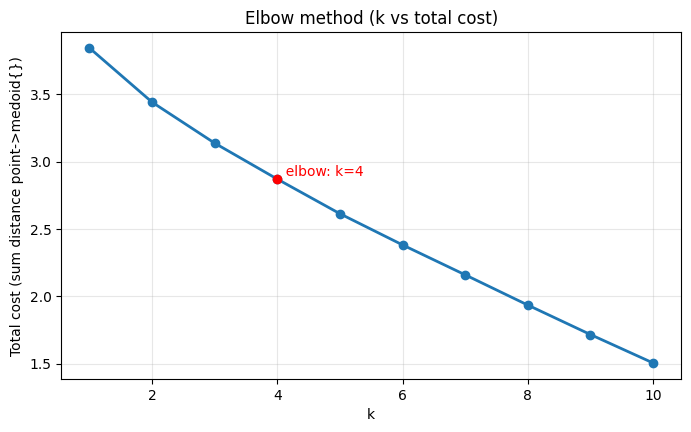

Suggested k for class 2: 4
[3.84474421 3.44224739 3.13800287 2.87097406 2.61409235 2.38247442
 2.1602788  1.93575466 1.71700609 1.50607264]


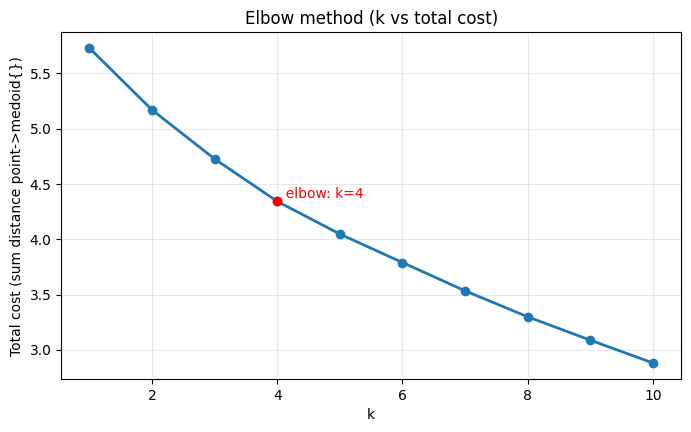

Suggested k for class 3: 4
[5.72918463 5.16987991 4.72617292 4.34267616 4.04683971 3.78946376
 3.53358531 3.29876065 3.0875082  2.88127875]
----------------------------------------------------------------------------------------------------
Train set size 1000:



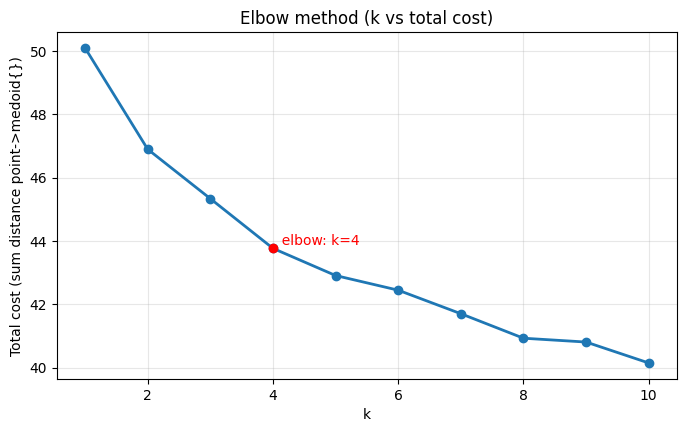

Suggested k for class 0: 4
[50.09324646 46.89460754 45.33375168 43.76396942 42.90634155 42.44289398
 41.70023727 40.92623901 40.80506134 40.14422989]


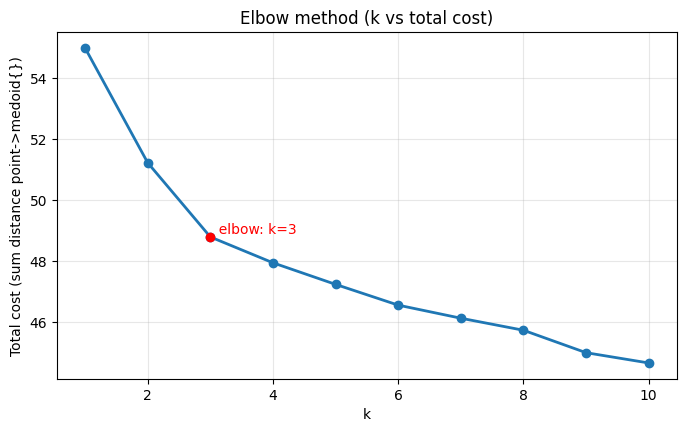

Suggested k for class 1: 3
[54.9800415  51.22136688 48.79244232 47.94548798 47.23892975 46.55914307
 46.13116074 45.73686981 45.00222778 44.66552734]


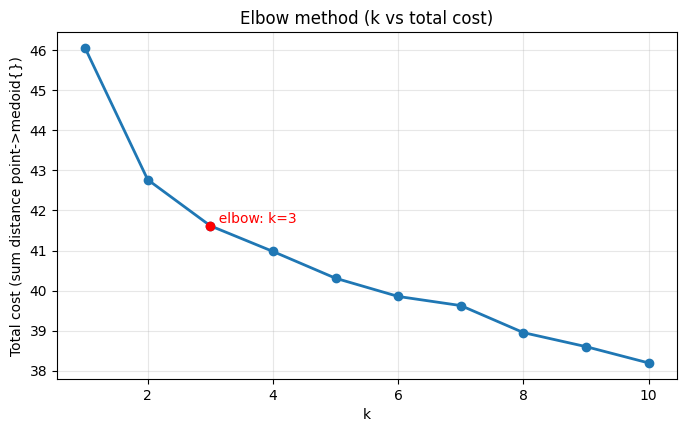

Suggested k for class 2: 3
[46.05364227 42.76792526 41.61753464 40.97774124 40.30967712 39.85525513
 39.62771988 38.95291901 38.60316086 38.19621277]


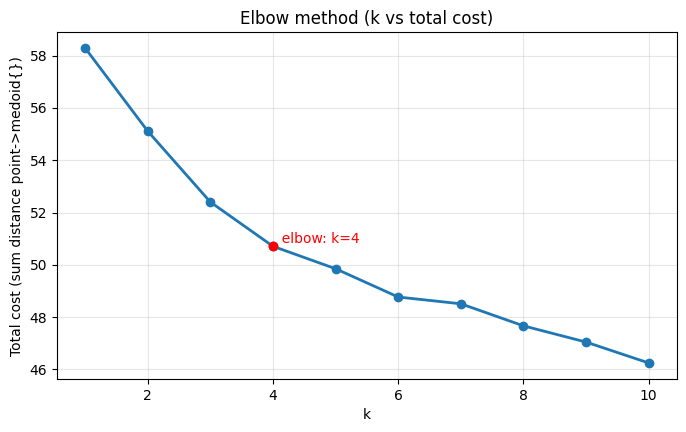

Suggested k for class 3: 4
[58.28891754 55.1114006  52.40128326 50.70900726 49.85113525 48.77008057
 48.51129913 47.6685791  47.04782104 46.24938202]
----------------------------------------------------------------------------------------------------
Train set size 10000:



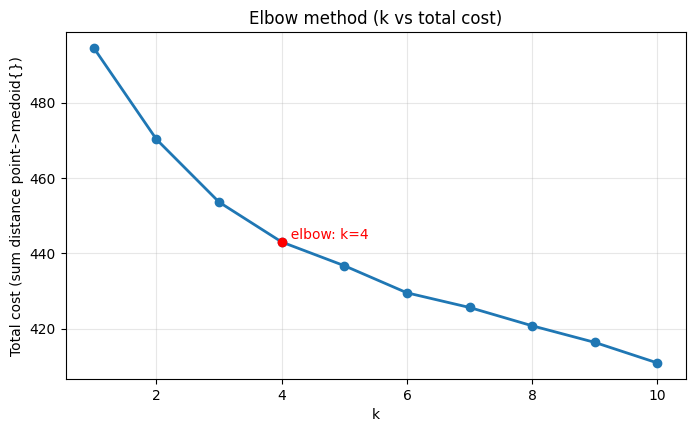

Suggested k for class 0: 4
[494.52548218 470.25674438 453.58465576 442.99310303 436.69995117
 429.5022583  425.60720825 420.74395752 416.33282471 410.8717041 ]


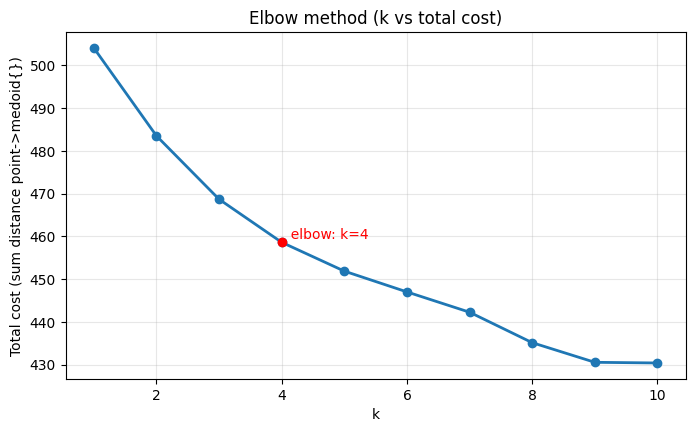

Suggested k for class 1: 4
[504.09350586 483.52648926 468.69564819 458.61782837 451.87854004
 447.01544189 442.2666626  435.14102173 430.54626465 430.3921814 ]


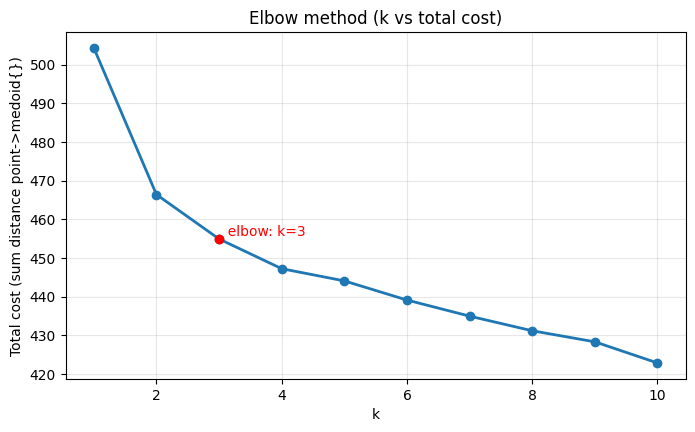

Suggested k for class 2: 3
[504.2857666  466.3961792  454.90618896 447.22741699 444.07330322
 439.12249756 434.96279907 431.18017578 428.32147217 422.85458374]


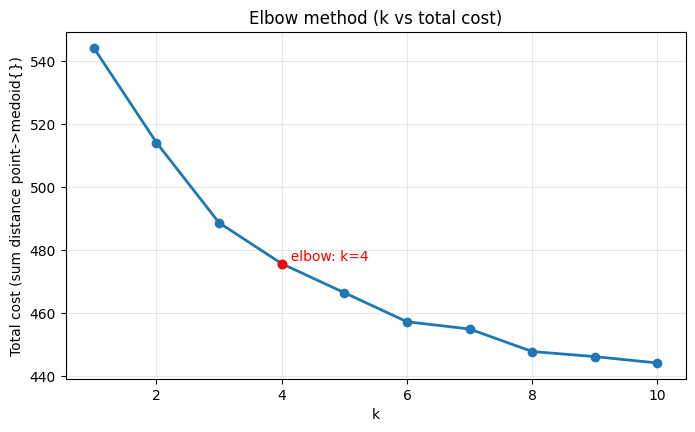

Suggested k for class 3: 4
[544.24938965 514.20007324 488.72827148 475.73394775 466.50521851
 457.27932739 454.97052002 447.81646729 446.20855713 444.18478394]
----------------------------------------------------------------------------------------------------
Medoid labels found for sentence-t5-base:
- on train set size 10:
Bangladesh strike opposition activist town city Bangladesh halt day people explosion political rally, african blunder public broadcaster Sabc apologise news bulletin footage American Iraq
Mutombo Rockets mentor Dikembe Mutombo trade deal Chicago Bulls Houston exchange Eric Piatkowski Adrian Griffin Mike Wilks Houston Chronicle, wrong Athens Matt Emmons calm right target
economy steam Fed district economy September early October Great Plains Rocky Mountain region Tenth Federal Reserve District Federal Reserve Bank Kansas City Wednesday, Rbc Centura Ceo Raleigh head Rbc Centura Bank successor bank Raleigh Rocky Mount bank
pitch Apple New iTunes ad baseball game Tuesd

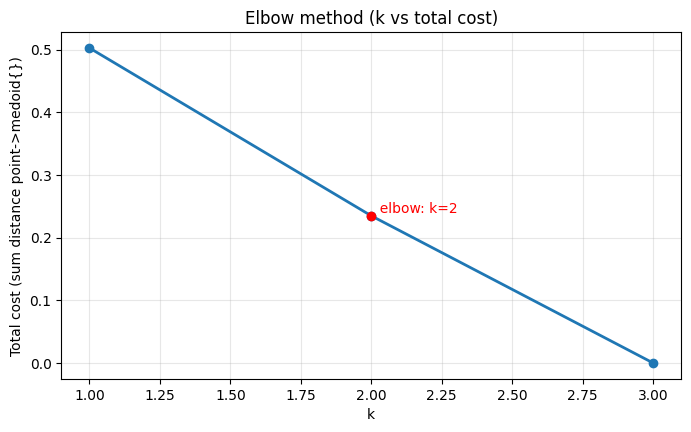

Suggested k for class 0: 2
[0.50259376 0.23482114 0.        ]


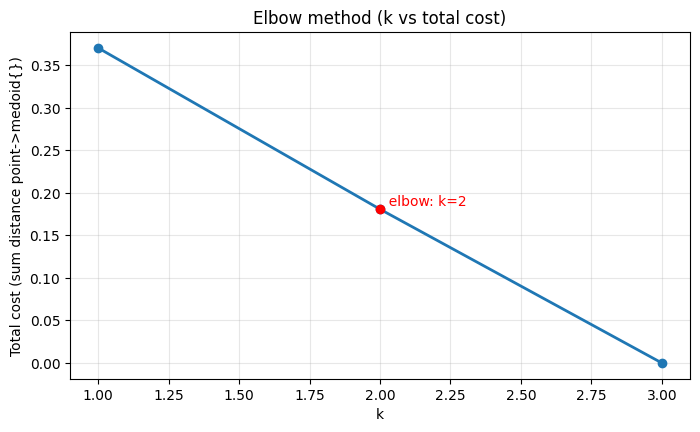

Suggested k for class 1: 2
[0.37057507 0.18087375 0.        ]


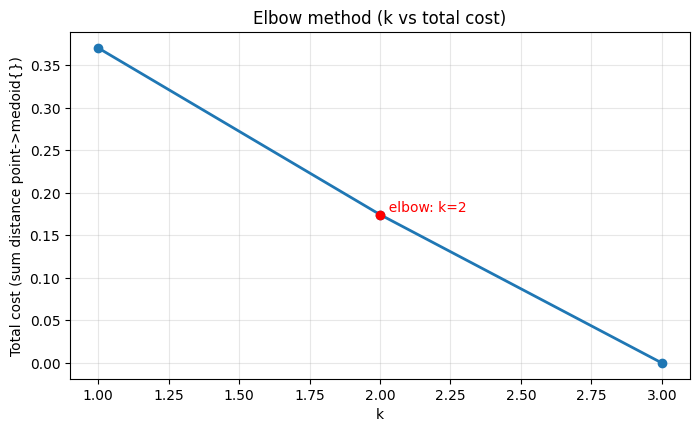

Suggested k for class 2: 2
[0.37056971 0.17453825 0.        ]


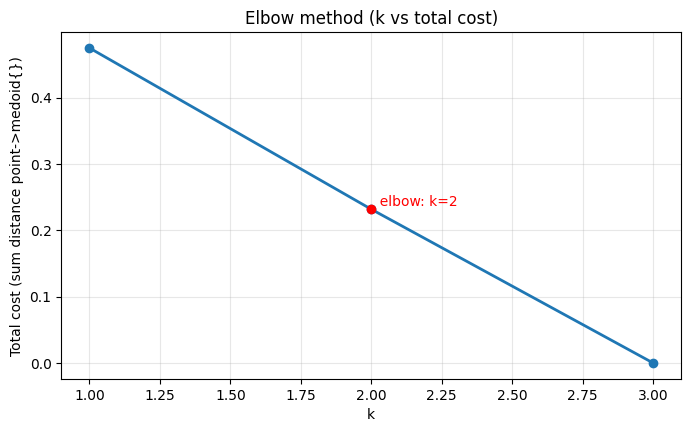

Suggested k for class 3: 2
[0.47467613 0.23164856 0.        ]
----------------------------------------------------------------------------------------------------
Train set size 100:



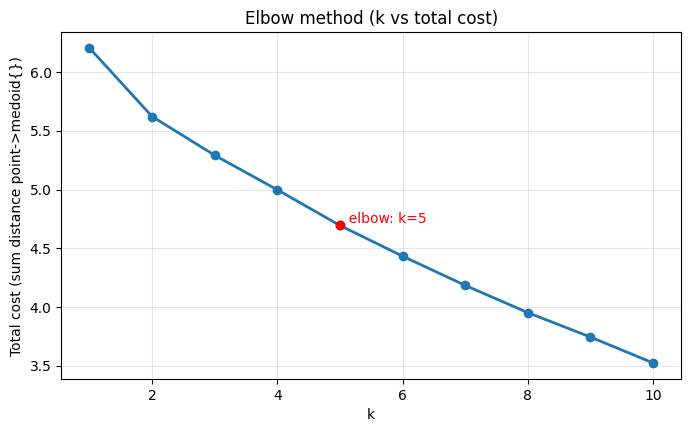

Suggested k for class 0: 5
[6.20464134 5.62146616 5.29147625 4.99779034 4.69407368 4.43303061
 4.18418264 3.95254326 3.74466562 3.5241003 ]


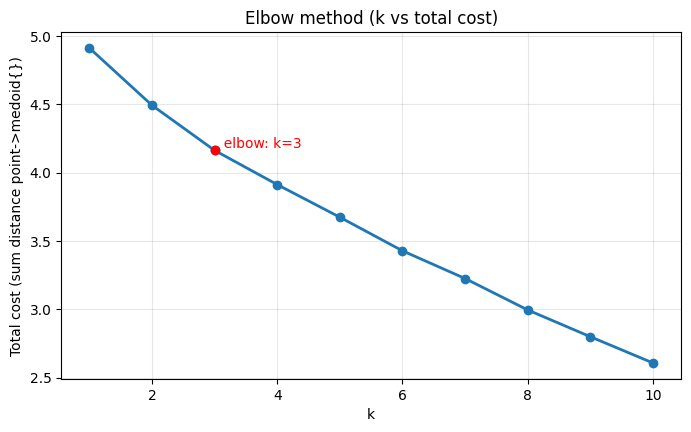

Suggested k for class 1: 3
[4.91242218 4.49314022 4.1627984  3.91248059 3.67373919 3.42782474
 3.22493052 2.99488616 2.79903054 2.60684419]


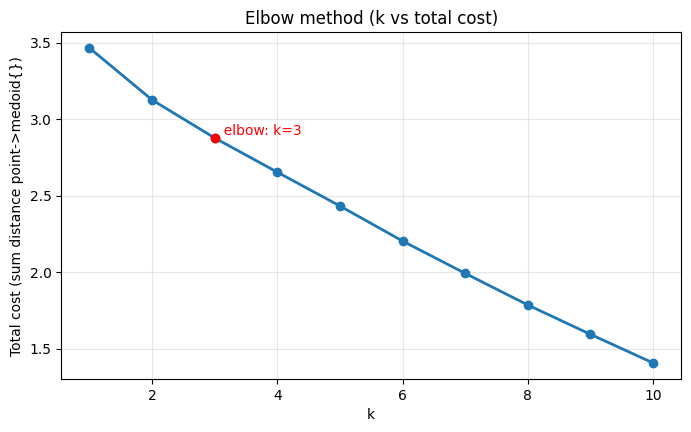

Suggested k for class 2: 3
[3.46437883 3.12527657 2.87667847 2.65321779 2.43236732 2.20346546
 1.99242437 1.78586924 1.59430134 1.40729988]


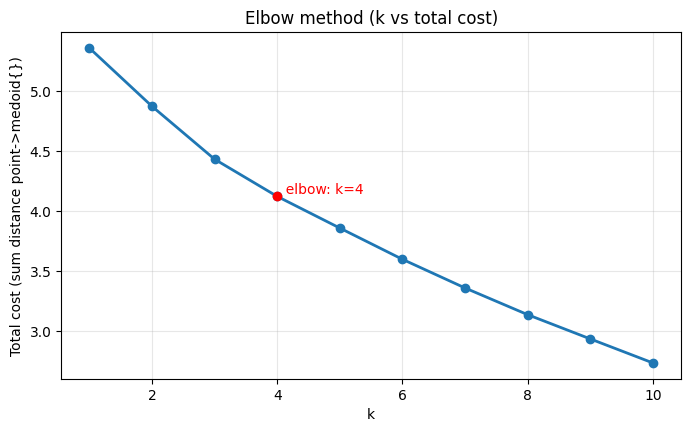

Suggested k for class 3: 4
[5.36302233 4.87675714 4.43503332 4.12487936 3.86073732 3.60004091
 3.36085296 3.13813686 2.93591928 2.73541784]
----------------------------------------------------------------------------------------------------
Train set size 1000:



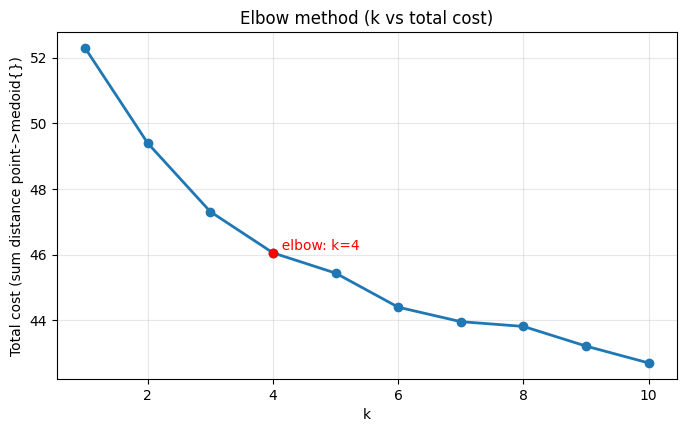

Suggested k for class 0: 4
[52.30069351 49.39818573 47.30776215 46.05171585 45.43458939 44.39477539
 43.9532547  43.80817413 43.2078743  42.69342422]


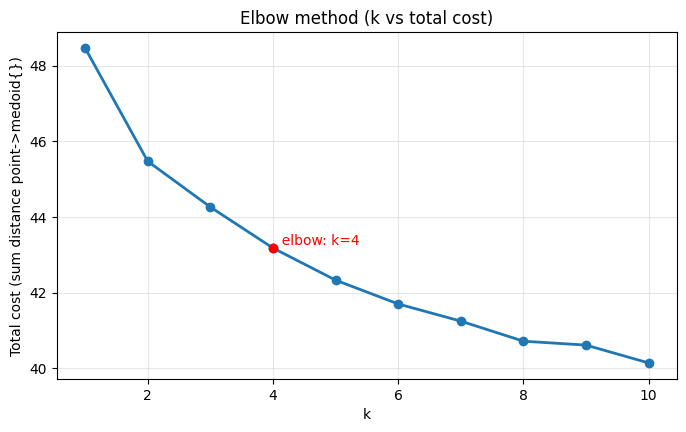

Suggested k for class 1: 4
[48.46333694 45.47132874 44.26176071 43.17923737 42.33132172 41.70174026
 41.24833298 40.71808624 40.61516571 40.14319229]


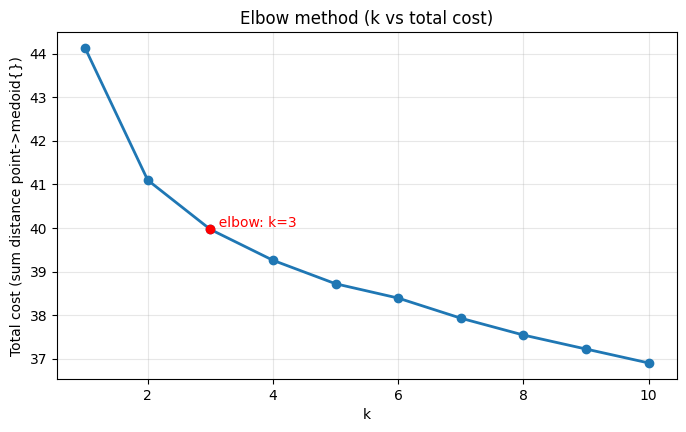

Suggested k for class 2: 3
[44.12823486 41.09783936 39.96749115 39.2591362  38.72099686 38.39229202
 37.93143845 37.54495239 37.22355652 36.90460968]


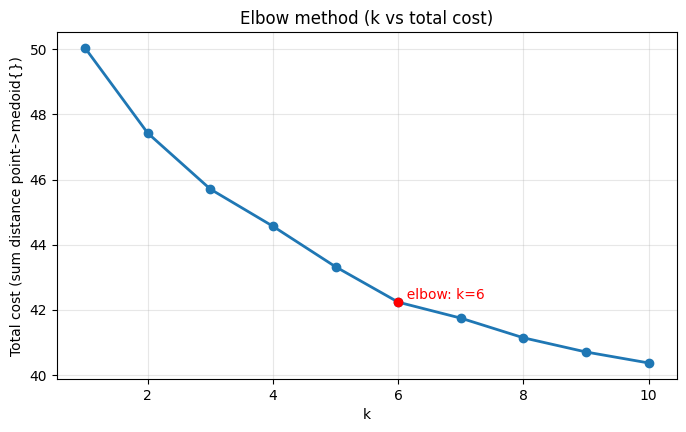

Suggested k for class 3: 6
[50.04005432 47.42697906 45.70641327 44.56531525 43.3216629  42.23555374
 41.74484253 41.14109039 40.70514679 40.36837006]
----------------------------------------------------------------------------------------------------
Train set size 10000:



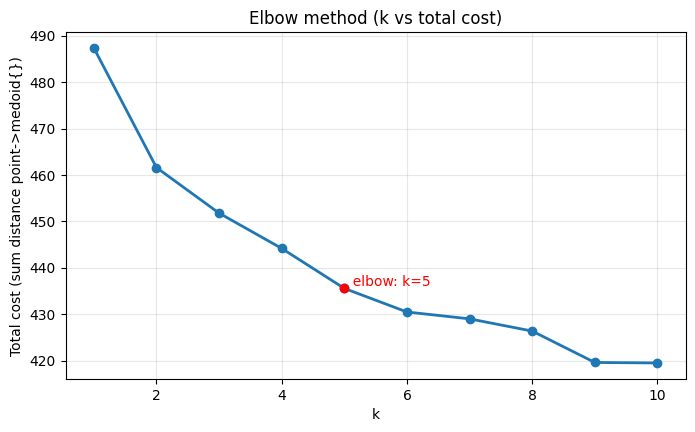

Suggested k for class 0: 5
[487.35559082 461.60101318 451.78778076 444.19122314 435.57897949
 430.49969482 429.02194214 426.38848877 419.62976074 419.52050781]


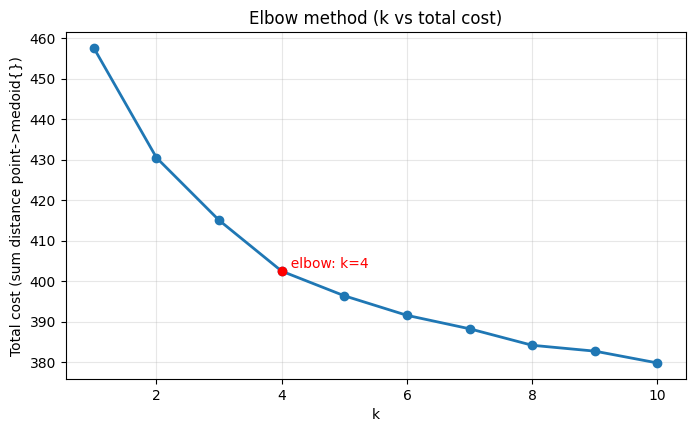

Suggested k for class 1: 4
[457.59747314 430.49981689 415.04135132 402.47015381 396.3927002
 391.56500244 388.24481201 384.17126465 382.72186279 379.80099487]


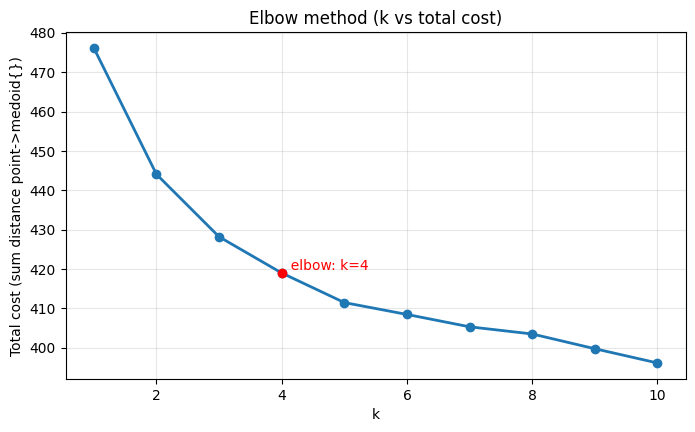

Suggested k for class 2: 4
[476.15466309 444.06958008 428.20080566 419.00720215 411.49307251
 408.47763062 405.34078979 403.5184021  399.77230835 396.15533447]


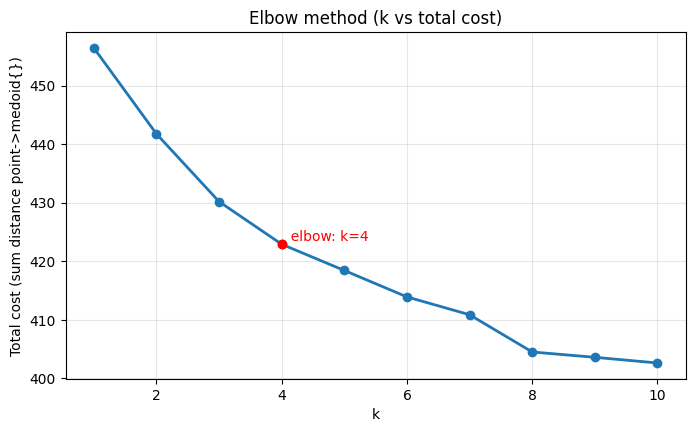

Suggested k for class 3: 4
[456.43713379 441.76306152 430.19741821 422.91925049 418.44042969
 413.9296875  410.88146973 404.52319336 403.61322021 402.64736938]
----------------------------------------------------------------------------------------------------
Medoid labels found for BAAI/bge-base-en:
- on train set size 10:
Bangladesh strike opposition activist town city Bangladesh halt day people explosion political rally, Putin power play russia safe Russia barrage terrorist attack school massacre Beslan
Mutombo Rockets mentor Dikembe Mutombo trade deal Chicago Bulls Houston exchange Eric Piatkowski Adrian Griffin Mike Wilks Houston Chronicle, wrong Athens Matt Emmons calm right target
economy steam Fed district economy September early October Great Plains Rocky Mountain region Tenth Federal Reserve District Federal Reserve Bank Kansas City Wednesday, Rbc Centura Ceo Raleigh head Rbc Centura Bank successor bank Raleigh Rocky Mount bank
pitch Apple New iTunes ad baseball game Tuesday

In [16]:
# NOTE: A more comprehensive dataset pipeline will be implemented in the future
# to support multiple datasets in a unified manner.
# This will include dataset selection, loading the corresponding training sets,
# setting the number of classes, and automatically computing documents per class.

# Chosen dataset
dataset_base_name = "AgNews"

# Precompute train sets
train_sets = {}
for n in TRAIN_SIZES:
    dataset_name = build_dataset_name(dataset_base_name, "train", n)
    train_sets[n] = load_data(dataset_name)

num_classes = get_num_classes(train_sets[10])

# Build one document for each class using the class texts
doc_classes = {}
for n, train_set in train_sets.items():
    doc_classes[n] = build_doc_classes(train_set, num_classes)

# List of medoid labels found by the embedding model for each training set
medoid_labels_by_model = {model_name: [] for model_name in model_list}

# For each model
for embedding_model, model_name in zip(models, model_list):
    print(f"{model_name}:")
    # Get the medoid labels list obtained on train sets
    medoid_labels_train_sets = run_medoid_labels_per_train_set(train_sets, embedding_model)

    print(f"Medoid labels found for {model_name}:")
    for n, medoid_labels in zip(TRAIN_SIZES, medoid_labels_train_sets):
        print(f"- on train set size {n}:")
        for label in medoid_labels:
            print(label)
        print()

    # Store the medoid labels list for each model
    medoid_labels_by_model[model_name].append(medoid_labels_train_sets)  

### Evaluate the models on the test set using the original class labels to establish a baseline performance

In [18]:
# Original AG News class labels as strings
train_set_10 = train_sets[10]
original_labels = train_set_10.features["label"].names
print(original_labels)

results_original_labels = {model_name: [] for model_name in model_list}

# Test each model with original labels
for embedding_model, model_name in zip(models, model_list):
    print("-" * 10)
    print(f"{model_name}:")
    # Initialize test evaluator
    evaluator = MultiMetricEvaluator(test_set, original_labels, "Test evaluator")
    # Compute test set metrics
    metrics = evaluator(embedding_model)
    print()
    print_metrics(metrics)

    # Store f1 score
    f1_score = metrics["f1_score"]
    results_original_labels[model_name].append(f1_score)

['World', 'Sports', 'Business', 'Sci/Tech']
----------
all-MiniLM-L6-v2:

Accuracy: 0.638
Precision: 0.6385859866276764
Recall: 0.6385859866276764
F1 Score: 0.6332318899601777
----------
all-mpnet-base-v2:

Accuracy: 0.589
Precision: 0.5977632110900326
Recall: 0.5977632110900326
F1 Score: 0.5864686679440778
----------
sentence-t5-base:

Accuracy: 0.668
Precision: 0.6940062753170595
Recall: 0.6940062753170595
F1 Score: 0.6550479578262736
----------
BAAI/bge-base-en:

Accuracy: 0.721
Precision: 0.7265089386109856
Recall: 0.7265089386109856
F1 Score: 0.7075600450338926


### Evaluate the models on the test set using the medoid labels obtained from each training set

In [19]:
dataset_name = build_dataset_name("AgNews", "test", 1000)
test_set = load_data(dataset_name)

In [20]:
results = {model_name: [] for model_name in model_list}

# Evaluate each model using the medoid labels found for each training set
for embedding_model, model_name in zip(models, model_list):
    print(f"Testing medoid labels for {model_name}:")
    
    medoid_labels_train_sets = medoid_labels_by_model[model_name]
    # For each medoid labels found in train_set i extract medoid labels in string format
    for medoid_labels_train_set in medoid_labels_train_sets:
        for n, medoid_labels in zip(TRAIN_SIZES, medoid_labels_train_set):
            print(f"- medoid_labels found on train set size {n}:\n")
            for label in medoid_labels:
                print(label)
            print()
            # Initialize an evaluator with medoids labels
            evaluator = MultiMetricEvaluator(test_set, medoid_labels, "Test evaluator")
            # Compute test metrics
            metrics = evaluator(embedding_model)
            print_metrics(metrics)
            print()

            # Store f1 score
            f1_score = metrics["f1_score"]
            results[model_name].append(f1_score)

        print("-"*100)

Testing medoid labels for all-MiniLM-L6-v2:
- medoid_labels found on train set size 10:

Bangladesh strike opposition activist town city Bangladesh halt day people explosion political rally, Putin power play russia safe Russia barrage terrorist attack school massacre Beslan
Mutombo Rockets mentor Dikembe Mutombo trade deal Chicago Bulls Houston exchange Eric Piatkowski Adrian Griffin Mike Wilks Houston Chronicle, wrong Athens Matt Emmons calm right target
economy steam Fed district economy September early October Great Plains Rocky Mountain region Tenth Federal Reserve District Federal Reserve Bank Kansas City Wednesday, Rbc Centura Ceo Raleigh head Rbc Centura Bank successor bank Raleigh Rocky Mount bank
pitch Apple New iTunes ad baseball game Tuesday advertising shy irish rocker, cosmic storm Galaxy Clusters Collide Astronomers perfect cosmic storm galaxy cluster pile powerful energy output second Big Bang

Accuracy: 0.545
Precision: 0.5505549075921597
Recall: 0.5505549075921597
F1 S

### Models’ F1-scores on the test set using original class labels and medoid labels obtained from training sets

In [29]:
print("Original class labels:\n")
for model_name, f1_score in results_original_labels.items():
    print(f"{model_name}: {results_original_labels[model_name]}")

print()

print("Medoid labels:\n")
for model_name, f1_score in results.items():
    print(f"{model_name}: {results[model_name]}")

Original class labels:

all-MiniLM-L6-v2: [0.6332318899601777]
all-mpnet-base-v2: [0.5864686679440778]
sentence-t5-base: [0.6550479578262736]
BAAI/bge-base-en: [0.7075600450338926]

Medoid labels:

all-MiniLM-L6-v2: [0.5433359369144584, 0.7005771219702447, 0.6829257890799683, 0.7011097451571818]
all-mpnet-base-v2: [0.5532248044054934, 0.7581507315066757, 0.7175097932122559, 0.7929101082591927]
sentence-t5-base: [0.5852363681202288, 0.7493920559147851, 0.7638312307821358, 0.791867282794029]
BAAI/bge-base-en: [0.589889081587468, 0.7488221935024257, 0.7902882681252675, 0.8167423768942491]


### Plot the models’ F1-scores on the test set using the medoid labels

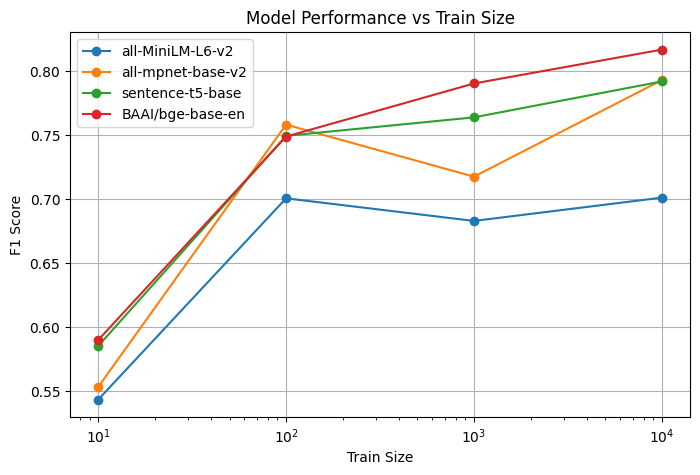

In [30]:
plt.figure(figsize=(8,5))
for model, metrics in results.items():
    plt.plot(TRAIN_SIZES, metrics, marker='o', label=model)

plt.xscale('log')
plt.xlabel("Train Size")
plt.ylabel("F1 Score")
plt.title("Model Performance vs Train Size")
plt.legend()
plt.grid(True)
plt.show()